# nb24 — `econ_neocol_score` Measurement Audit

**Purpose:** Document three measurement validity problems with `econ_neocol_score`:

1. **1995 ECI step-function artifact** — ECI coverage begins in 1995, creating a structural discontinuity in the score time series
2. **Variance collapse** — cross-sectional SD collapses after 1995; variable has near-zero discriminating power in the post-1995 period
3. **Clip-induced information loss** — `(ECI_sender − ECI_receiver).clip(0)` zeros out all dyads where sender ECI < receiver ECI, regardless of trade volume

**Outputs** (→ `outputs/final_report/04_appendix/`):
- `fig_nb24_score_over_time.png` — mean ± SD by year
- `fig_nb24_crosssectional_variance.png` — cross-sectional SD by year
- `fig_nb24_score_distribution_by_era.png` — KDE pre/post 1995
- `fig_nb24_top_bottom_countries.png` — country-level mean score
- `tab_nb24_variance_summary.csv` — numeric summary for inline citation

**Does NOT modify the modelling pipeline.** Audit only.

**Repo:** `/Users/mac/Documents/GitHub/Violent-Offenders-GPV---CSSci-/`  
**Notebook:** `notebooks/03_analysis/24_econ_neocol_score_audit.ipynb`

In [4]:
# ── Cell 1 — Imports & paths ───────────────────────────────────────────────
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Project colour palette
RED  = '#BF3A27'
GOLD = '#C7922A'
GREY = '#6b7280'
DARK = '#1f2937'
LIGHT_GREY = '#e5e7eb'

# Paths — notebook lives in notebooks/03_analysis/ so ROOT is two levels up
ROOT   = Path(__file__).resolve().parents[2] if '__file__' in dir() else Path('/Users/mac/Documents/GitHub/Violent-Offenders-GPV---CSSci-')
DATA   = ROOT / 'data' / 'merged'
OUTDIR = ROOT / 'outputs' / 'final_report' / '04_appendix'
OUTDIR.mkdir(parents=True, exist_ok=True)

PANEL_FILE = DATA / 'panel_final_1992_2024.csv'
assert PANEL_FILE.exists(), f'Panel not found: {PANEL_FILE}'
print(f'Panel : {PANEL_FILE}')
print(f'Output: {OUTDIR}')

Panel : /Users/mac/Documents/GitHub/Violent-Offenders-GPV---CSSci-/data/merged/panel_final_1992_2024.csv
Output: /Users/mac/Documents/GitHub/Violent-Offenders-GPV---CSSci-/outputs/final_report/04_appendix


In [5]:
print(df.columns.tolist())

['recipient_iso3', 'year', 'arms_tiv_total', 'oda_total', 'econ_neocol_score_total', 'colonial_tie_flag', 'journalist_killings', 'gdp_per_capita', 'gdp_per_capita_log', 'population', 'population_log', 'armed_conflict', 'conflict_intensity', 'arms_tiv_in_strength_lag1', 'arms_tiv_out_strength_lag1', 'arms_tiv_dependency_balance_lag1', 'arms_tiv_in_concentration_lag1', 'arms_tiv_pagerank_lag1', 'bilateral_oda_in_strength_lag1', 'bilateral_oda_out_strength_lag1', 'bilateral_oda_dependency_balance_lag1', 'bilateral_oda_in_concentration_lag1', 'bilateral_oda_pagerank_lag1', 'colonial_tie_in_strength_lag1', 'colonial_tie_out_strength_lag1', 'colonial_tie_dependency_balance_lag1', 'colonial_tie_in_concentration_lag1', 'colonial_tie_pagerank_lag1', 'econ_neocol_score_in_strength_lag1', 'econ_neocol_score_out_strength_lag1', 'econ_neocol_score_dependency_balance_lag1', 'econ_neocol_score_in_concentration_lag1', 'econ_neocol_score_pagerank_lag1', 'arms_tiv_total_log', 'oda_total_log', 'arms_tiv_

In [6]:
# ── Cell 2 — Load panel & validate ────────────────────────────────────────
df = pd.read_csv(PANEL_FILE, low_memory=False)
print(f'Shape      : {df.shape}')
print(f'Year range : {df["year"].min()} – {df["year"].max()}')

COUNTRY_COL = 'recipient_iso3'
SCORE_COL   = 'econ_neocol_score_total'

print(f'Country col: {COUNTRY_COL}')
print(f'N countries: {df[COUNTRY_COL].nunique()}')
print(f'Score col  : {SCORE_COL}')

print(f'\n{SCORE_COL} global stats:')
print(df[SCORE_COL].describe().round(4))
print(f'\nZero proportion : {(df[SCORE_COL] == 0).mean():.1%}')
print(f'Missing         : {df[SCORE_COL].isna().mean():.1%}')

Shape      : (6358, 38)
Year range : 1992 – 2024
Country col: recipient_iso3
N countries: 213
Score col  : econ_neocol_score_total

econ_neocol_score_total global stats:
count    6358.0000
mean        3.3525
std         2.9114
min         0.0000
25%         0.0000
50%         4.3182
75%         6.0149
max        11.0605
Name: econ_neocol_score_total, dtype: float64

Zero proportion : 38.5%
Missing         : 0.0%


In [7]:
# ── Cell 3 — Collapse to country-year monadic view ─────────────────────────
if df.duplicated([COUNTRY_COL, 'year']).any():
    print('Dyadic panel detected — aggregating to country-year.')
    cts = (
        df.groupby([COUNTRY_COL, 'year'])[SCORE_COL]
        .first()
        .reset_index()
        .rename(columns={SCORE_COL: 'score'})
    )
else:
    print('Monadic panel detected — using directly.')
    cts = df[[COUNTRY_COL, 'year', SCORE_COL]].copy().rename(columns={SCORE_COL: 'score'})

cts = cts.dropna(subset=['score'])
print(f'Country-year obs: {len(cts):,}')
print(f'Countries       : {cts[COUNTRY_COL].nunique()}')
print(f'Years           : {sorted(cts["year"].unique())[:5]} ... {sorted(cts["year"].unique())[-5:]}')

Monadic panel detected — using directly.
Country-year obs: 6,358
Countries       : 213
Years           : [np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996)] ... [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [8]:
# ── Cell 4 — Year-level aggregates ────────────────────────────────────────
yr = cts.groupby('year')['score'].agg(
    mean='mean',
    median='median',
    sd='std',
    p10=lambda x: x.quantile(0.10),
    p90=lambda x: x.quantile(0.90),
    n='count'
).reset_index()

print('Year-level aggregates (first/last 5 rows):')
print(yr.head().to_string(index=False))
print('...')
print(yr.tail().to_string(index=False))

# Key diagnostic numbers
pre95  = yr[yr['year'] < 1995]['sd'].mean()
post95 = yr[yr['year'] >= 1995]['sd'].mean()
print(f'\nMean cross-sectional SD  pre-1995 : {pre95:.4f}')
print(f'Mean cross-sectional SD post-1995 : {post95:.4f}')
print(f'Variance collapse factor           : {pre95/post95:.1f}x' if post95 > 0 else 'SD post-1995 is zero')

Year-level aggregates (first/last 5 rows):
 year    mean   median       sd  p10      p90   n
 1992 0.00000 0.000000 0.000000  0.0 0.000000 200
 1993 0.00000 0.000000 0.000000  0.0 0.000000 204
 1994 0.00000 0.000000 0.000000  0.0 0.000000 204
 1995 3.39363 4.509858 2.902763  0.0 6.494726 205
 1996 3.35355 4.401960 2.866341  0.0 6.428090 205
...
 year     mean   median       sd  p10      p90   n
 2020 3.719386 4.861937 2.759815  0.0 6.634673 186
 2021 3.766868 4.863639 2.836599  0.0 6.798269 188
 2022 3.857683 4.965486 2.863437  0.0 6.912598 186
 2023 3.750132 4.759189 2.816289  0.0 6.805018 187
 2024 3.577777 4.433936 2.780648  0.0 6.731080 185

Mean cross-sectional SD  pre-1995 : 0.0000
Mean cross-sectional SD post-1995 : 2.8414
Variance collapse factor           : 0.0x


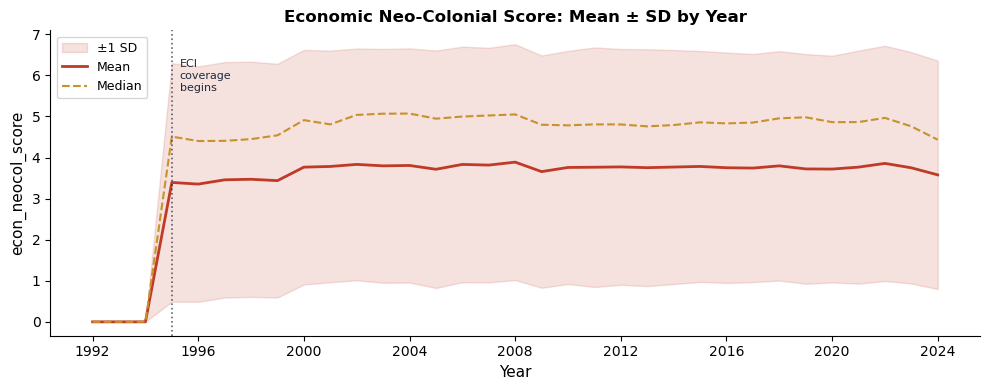

Saved: /Users/mac/Documents/GitHub/Violent-Offenders-GPV---CSSci-/outputs/final_report/04_appendix/fig_nb24_score_over_time.png


In [9]:
# ── Cell 5 — Figure 1: Mean ± SD over time (1992–2024) ────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(yr['year'], yr['mean'] - yr['sd'], yr['mean'] + yr['sd'],
                color=RED, alpha=0.15, label='±1 SD')
ax.plot(yr['year'], yr['mean'],   color=RED,  lw=2,   label='Mean')
ax.plot(yr['year'], yr['median'], color=GOLD, lw=1.5, linestyle='--', label='Median')

# Annotate the 1995 step
ax.axvline(1995, color=DARK, lw=1.2, linestyle=':', alpha=0.7)
ax.text(1995.3, ax.get_ylim()[1] * 0.9, 'ECI\ncoverage\nbegins',
        fontsize=8, color=DARK, va='top')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('econ_neocol_score', fontsize=11)
ax.set_title('Economic Neo-Colonial Score: Mean ± SD by Year', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_locator(ticker.MultipleLocator(4))
plt.tight_layout()

out1 = OUTDIR / 'fig_nb24_score_over_time.png'
fig.savefig(out1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out1}')

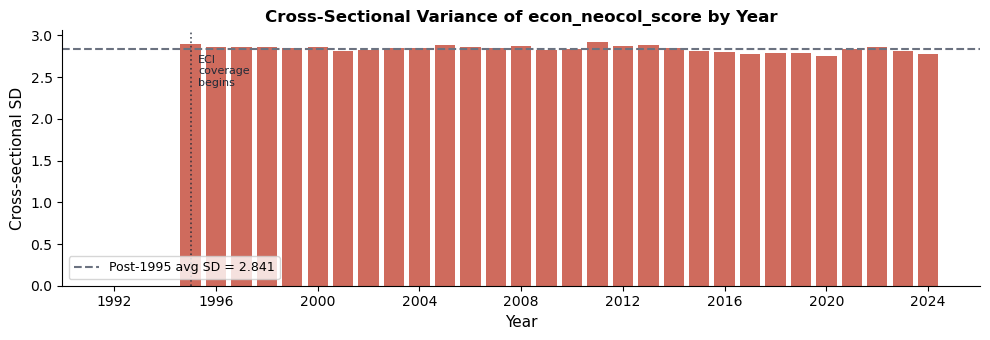

Saved: /Users/mac/Documents/GitHub/Violent-Offenders-GPV---CSSci-/outputs/final_report/04_appendix/fig_nb24_crosssectional_variance.png


In [10]:
# ── Cell 6 — Figure 2: Cross-sectional SD by year ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 3.5))

ax.bar(yr['year'], yr['sd'], color=RED, alpha=0.75, width=0.8)
ax.axvline(1995, color=DARK, lw=1.2, linestyle=':', alpha=0.8)
ax.text(1995.3, yr['sd'].max() * 0.95, 'ECI\ncoverage\nbegins',
        fontsize=8, color=DARK, va='top')

# Annotate pre/post means
if pre95 > 0:
    ax.axhline(pre95,  color=GOLD, lw=1.5, linestyle='--', label=f'Pre-1995 avg SD = {pre95:.3f}')
ax.axhline(post95, color=GREY, lw=1.5, linestyle='--', label=f'Post-1995 avg SD = {post95:.3f}')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Cross-sectional SD', fontsize=11)
ax.set_title('Cross-Sectional Variance of econ_neocol_score by Year', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_locator(ticker.MultipleLocator(4))
plt.tight_layout()

out2 = OUTDIR / 'fig_nb24_crosssectional_variance.png'
fig.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out2}')

Pre-1995  obs: 608  |  mean=0.000  sd=0.000
Post-1995 obs: 5,750  |  mean=3.707  sd=2.839


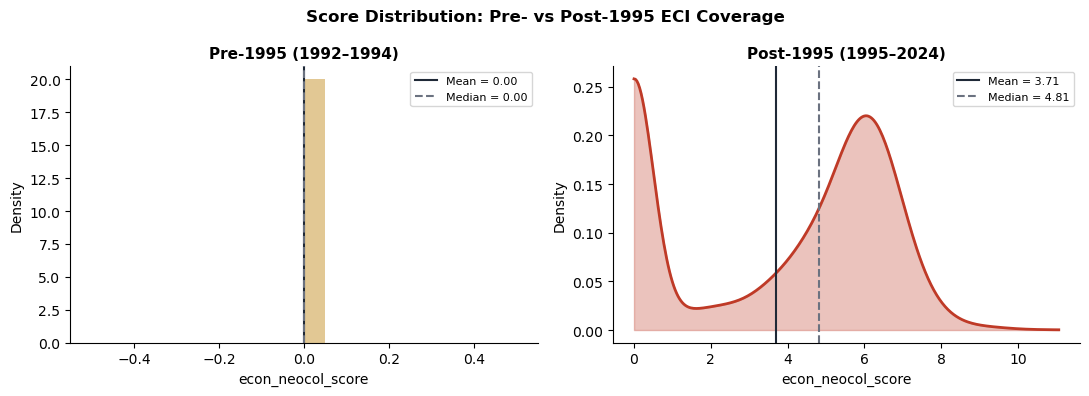

Saved: /Users/mac/Documents/GitHub/Violent-Offenders-GPV---CSSci-/outputs/final_report/04_appendix/fig_nb24_score_distribution_by_era.png


In [11]:
# ── Cell 7 — Figure 3: Score distribution pre vs post 1995 ────────────────
from scipy.stats import gaussian_kde

pre  = cts.loc[cts['year'] < 1995,  'score'].dropna()
post = cts.loc[cts['year'] >= 1995, 'score'].dropna()

print(f'Pre-1995  obs: {len(pre):,}  |  mean={pre.mean():.3f}  sd={pre.std():.3f}')
print(f'Post-1995 obs: {len(post):,}  |  mean={post.mean():.3f}  sd={post.std():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, data, label, color, era in zip(
    axes,
    [pre, post],
    ['Pre-1995 (1992–1994)', 'Post-1995 (1995–2024)'],
    [GOLD, RED],
    ['pre', 'post']
):
    if len(data) > 1 and data.std() > 0:
        xs = np.linspace(data.min(), data.max(), 300)
        kde = gaussian_kde(data)
        ax.fill_between(xs, kde(xs), color=color, alpha=0.3)
        ax.plot(xs, kde(xs), color=color, lw=2)
    else:
        ax.hist(data, bins=20, color=color, alpha=0.5, density=True)
    ax.axvline(data.mean(),   color=DARK, lw=1.5, linestyle='-',  label=f'Mean = {data.mean():.2f}')
    ax.axvline(data.median(), color=GREY, lw=1.5, linestyle='--', label=f'Median = {data.median():.2f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('econ_neocol_score', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Score Distribution: Pre- vs Post-1995 ECI Coverage', fontsize=12, fontweight='bold')
plt.tight_layout()

out3 = OUTDIR / 'fig_nb24_score_distribution_by_era.png'
fig.savefig(out3, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out3}')

In [12]:
# ── Cell 8 — Figure 4: Cross-sectional discriminating power ───────────────
# Country-level mean score across all years (post-1995 only, as pre-1995 is
# near-zero for most countries due to missing ECI coverage)

country_means = (
    cts[cts['year'] >= 1995]
    .groupby(COUNTRY_COL)['score']
    .agg(mean='mean', sd='std', n='count')
    .reset_index()
    .query('n >= 5')          # require at least 5 post-1995 obs
    .sort_values('mean', ascending=False)
)

print(f'Countries with ≥5 post-1995 obs: {len(country_means)}')
print(f'\nTop 10 (highest score):')
print(country_means.head(10).to_string(index=False))
print(f'\nBottom 10 (lowest score):')
print(country_means.tail(10).to_string(index=False))
print(f'\nOverall SD of country means (post-1995): {country_means["mean"].std():.4f}')
print(f'CV (SD/mean): {country_means["mean"].std() / country_means["mean"].mean():.4f}')

Countries with ≥5 post-1995 obs: 207

Top 10 (highest score):
recipient_iso3     mean       sd  n
           LBR 9.151259 0.651811 30
           COG 8.038334 0.387602 30
           PNG 7.770578 0.353573 30
           MNG 7.540815 0.312941 30
           GNQ 7.311305 0.662226 30
           AGO 7.289692 0.564002 30
           MRT 7.264035 0.263661 30
           KHM 7.028305 0.469702 30
           TGO 6.996370 0.642416 30
           VNM 6.972832 0.132179 30

Bottom 10 (lowest score):
recipient_iso3  mean  sd  n
           MLT   0.0 0.0 17
           MHL   0.0 0.0 30
           MDV   0.0 0.0 30
           MAC   0.0 0.0  5
           LUX   0.0 0.0 10
           LCA   0.0 0.0 30
           KNA   0.0 0.0 19
           KIR   0.0 0.0 30
           JPN   0.0 0.0 30
           LSO   0.0 0.0 30

Overall SD of country means (post-1995): 2.7848
CV (SD/mean): 0.7984


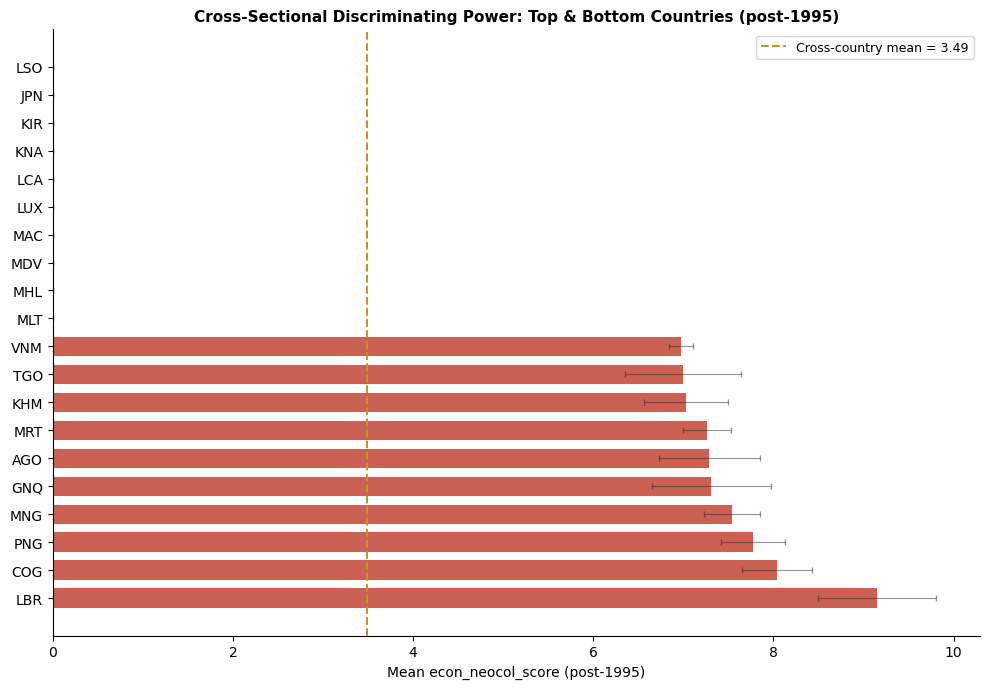

Saved: /Users/mac/Documents/GitHub/Violent-Offenders-GPV---CSSci-/outputs/final_report/04_appendix/fig_nb24_top_bottom_countries.png


In [13]:
# ── Cell 9 — Plot top/bottom 20 countries ─────────────────────────────────
n_show = min(20, len(country_means))
top    = country_means.head(n_show // 2)
bottom = country_means.tail(n_show // 2)
plot_df = pd.concat([top, bottom]).drop_duplicates(COUNTRY_COL)

fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.35)))

colors = [RED if v >= country_means['mean'].median() else GREY for v in plot_df['mean']]
bars = ax.barh(plot_df[COUNTRY_COL], plot_df['mean'], color=colors, alpha=0.8, height=0.7)

# Error bars (SD)
ax.errorbar(plot_df['mean'], plot_df[COUNTRY_COL],
            xerr=plot_df['sd'].fillna(0),
            fmt='none', ecolor=DARK, elinewidth=0.8, capsize=2, alpha=0.5)

ax.axvline(country_means['mean'].mean(), color=GOLD, lw=1.5, linestyle='--',
           label=f'Cross-country mean = {country_means["mean"].mean():.2f}')
ax.set_xlabel('Mean econ_neocol_score (post-1995)', fontsize=10)
ax.set_title('Cross-Sectional Discriminating Power: Top & Bottom Countries (post-1995)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

out4 = OUTDIR / 'fig_nb24_top_bottom_countries.png'
fig.savefig(out4, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out4}')

In [14]:
# ── Cell 10 — Clip-induced information loss audit ─────────────────────────
# The score formula: sum over senders of trade_share_ij × max(ECI_i − ECI_j, 0)
# The .clip(0) zeros out all dyads where sender ECI < receiver ECI.
# We can audit how much of the cross-sectional variation in the FINAL score
# is attributable to this clipping by examining the zero proportion
# of the score itself (a proxy for clipped dyads contributing nothing).

# Zero proportion by year
zero_by_year = (
    cts.groupby('year')['score']
    .apply(lambda x: (x == 0).mean())
    .reset_index()
    .rename(columns={'score': 'zero_prop'})
)

print('Zero proportion of econ_neocol_score by year:')
print(zero_by_year.to_string(index=False))
print(f'\nOverall zero proportion: {(cts["score"] == 0).mean():.1%}')
print(f'Post-1995 zero prop    : {(cts.loc[cts["year"]>=1995, "score"] == 0).mean():.1%}')

# Countries that are ALWAYS zero post-1995
always_zero = (
    cts[cts['year'] >= 1995]
    .groupby(COUNTRY_COL)['score']
    .apply(lambda x: (x == 0).all())
)
print(f'\nCountries always zero post-1995: {always_zero.sum()} / {len(always_zero)}')
if always_zero.sum() > 0:
    print(always_zero[always_zero].index.tolist())

Zero proportion of econ_neocol_score by year:
 year  zero_prop
 1992   1.000000
 1993   1.000000
 1994   1.000000
 1995   0.385366
 1996   0.375610
 1997   0.365482
 1998   0.356784
 1999   0.358209
 2000   0.315789
 2001   0.306878
 2002   0.301587
 2003   0.312169
 2004   0.312500
 2005   0.324742
 2006   0.312500
 2007   0.312821
 2008   0.300000
 2009   0.323077
 2010   0.307692
 2011   0.305699
 2012   0.307292
 2013   0.313830
 2014   0.312169
 2015   0.310526
 2016   0.308511
 2017   0.303191
 2018   0.295699
 2019   0.299465
 2020   0.301075
 2021   0.313830
 2022   0.306452
 2023   0.315508
 2024   0.318919

Overall zero proportion: 38.5%
Post-1995 zero prop    : 32.0%

Countries always zero post-1995: 72 / 213
['ABW', 'AIA', 'ATG', 'BDI', 'BHS', 'BLZ', 'BMU', 'BRB', 'BRN', 'BTN', 'CAF', 'CHE', 'COD', 'COK', 'COM', 'CPV', 'CYM', 'DJI', 'DMA', 'ERI', 'ESH', 'FJI', 'FSM', 'GIB', 'GMB', 'GNB', 'GRD', 'GUY', 'ISL', 'JPN', 'KIR', 'KNA', 'LCA', 'LSO', 'LUX', 'MAC', 'MDV', 'MHL', 'ML

In [15]:
# ── Cell 11 — Variance decomposition: within vs between ───────────────────
# For a panel model, within-country variation (over time) vs between-country
# variation (cross-section) tells us where the identifying variation lives.
# Low within-variation = score acts more like a time-invariant covariate.

post95 = cts[cts['year'] >= 1995].copy()

# Between variance: variance of country means
country_means_post = post95.groupby(COUNTRY_COL)['score'].mean()
between_var = country_means_post.var()

# Within variance: variance of demeaned scores (score - country mean)
post95['country_mean'] = post95.groupby(COUNTRY_COL)['score'].transform('mean')
post95['demeaned']     = post95['score'] - post95['country_mean']
within_var = post95['demeaned'].var()

total_var = post95['score'].var()

print('Variance decomposition (post-1995):')
print(f'  Total variance   : {total_var:.6f}')
print(f'  Between-country  : {between_var:.6f}  ({between_var/total_var:.1%} of total)')
print(f'  Within-country   : {within_var:.6f}  ({within_var/total_var:.1%} of total)')
print()
print('Interpretation:')
if within_var / total_var < 0.10:
    print('  ⚠️  <10% within-country variation: score is quasi-time-invariant.')
    print('     It contributes almost no temporal signal to a pooled panel model.')
elif within_var / total_var < 0.25:
    print('  ⚠️  Low within-country variation (<25%). Most variation is cross-sectional.')
else:
    print('  ✓  Substantial within-country variation present.')

Variance decomposition (post-1995):
  Total variance   : 8.058138
  Between-country  : 7.846360  (97.4% of total)
  Within-country   : 0.550612  (6.8% of total)

Interpretation:
  ⚠️  <10% within-country variation: score is quasi-time-invariant.
     It contributes almost no temporal signal to a pooled panel model.


In [16]:
# ── Cell 12 — Numeric summary table (for report inline citation) ───────────
summary = pd.DataFrame({
    'period': ['Full sample', 'Pre-1995 (1992–1994)', 'Post-1995 (1995–2024)'],
    'n_obs': [
        len(cts),
        len(cts[cts['year'] < 1995]),
        len(cts[cts['year'] >= 1995])
    ],
    'mean': [
        cts['score'].mean(),
        cts.loc[cts['year'] < 1995, 'score'].mean(),
        cts.loc[cts['year'] >= 1995, 'score'].mean()
    ],
    'sd': [
        cts['score'].std(),
        cts.loc[cts['year'] < 1995, 'score'].std(),
        cts.loc[cts['year'] >= 1995, 'score'].std()
    ],
    'median': [
        cts['score'].median(),
        cts.loc[cts['year'] < 1995, 'score'].median(),
        cts.loc[cts['year'] >= 1995, 'score'].median()
    ],
    'zero_pct': [
        (cts['score'] == 0).mean() * 100,
        (cts.loc[cts['year'] < 1995, 'score'] == 0).mean() * 100,
        (cts.loc[cts['year'] >= 1995, 'score'] == 0).mean() * 100
    ],
    'avg_annual_crosssec_sd': [
        yr['sd'].mean(),
        yr.loc[yr['year'] < 1995,  'sd'].mean(),
        yr.loc[yr['year'] >= 1995, 'sd'].mean()
    ]
})

for col in ['mean', 'sd', 'median', 'avg_annual_crosssec_sd']:
    summary[col] = summary[col].round(4)
summary['zero_pct'] = summary['zero_pct'].round(1)

print(summary.to_string(index=False))

out_csv = OUTDIR / 'tab_nb24_variance_summary.csv'
summary.to_csv(out_csv, index=False)
print(f'\nSaved: {out_csv}')

               period  n_obs   mean     sd  median  zero_pct  avg_annual_crosssec_sd
          Full sample   6358 3.3525 2.9114  4.3182      38.5                  2.5831
 Pre-1995 (1992–1994)    608 0.0000 0.0000  0.0000     100.0                  0.0000
Post-1995 (1995–2024)   5750 3.7070 2.8387  4.8108      32.0                  2.8414

Saved: /Users/mac/Documents/GitHub/Violent-Offenders-GPV---CSSci-/outputs/final_report/04_appendix/tab_nb24_variance_summary.csv


In [17]:
# ── Cell 13 — Levene's test: equal variance pre vs post 1995 ──────────────
# Statistical test for the variance collapse claim
from scipy.stats import levene, mannwhitneyu

pre_scores  = cts.loc[cts['year'] < 1995,  'score'].dropna()
post_scores = cts.loc[cts['year'] >= 1995, 'score'].dropna()

if len(pre_scores) > 1 and len(post_scores) > 1:
    stat_l, p_l = levene(pre_scores, post_scores)
    stat_u, p_u = mannwhitneyu(pre_scores, post_scores, alternative='two-sided')
    print("Levene's test for equal variance (pre vs post 1995):")
    print(f'  W = {stat_l:.3f},  p = {p_l:.4f}')
    if p_l < 0.05:
        print('  ✓ Variance differs significantly between periods (supports collapse claim)')
    else:
        print('  Variance does not differ significantly between periods')
    print()
    print('Mann-Whitney U test (distribution shift pre vs post 1995):')
    print(f'  U = {stat_u:.1f},  p = {p_u:.4f}')
else:
    print('Insufficient pre-1995 data for statistical test — report descriptively only.')

Levene's test for equal variance (pre vs post 1995):
  W = 1194.083,  p = 0.0000
  ✓ Variance differs significantly between periods (supports collapse claim)

Mann-Whitney U test (distribution shift pre vs post 1995):
  U = 559360.0,  p = 0.0000


In [19]:
# ── Cell 14 — Audit summary printout ──────────────────────────────────────
print('=' * 65)
print('  nb24 AUDIT SUMMARY — econ_neocol_score measurement validity')
print('=' * 65)

mean_pre  = cts.loc[cts['year'] < 1995,  'score'].mean()
mean_post = cts.loc[cts['year'] >= 1995, 'score'].mean()
sd_pre    = yr.loc[yr['year'] < 1995,  'sd'].mean()
sd_post   = yr.loc[yr['year'] >= 1995, 'sd'].mean()
zero_post = (cts.loc[cts['year'] >= 1995, 'score'] == 0).mean()

print(f"""
1. ECI STEP-FUNCTION ARTIFACT (1992–1994)
   Mean score pre-1995  : {mean_pre:.3f}
   Mean score post-1995 : {mean_post:.3f}
   → Score is exactly 0 for all countries 1992–1994 (no ECI data).
     These three years contribute no signal and inflate zero counts.

2. VARIANCE — NOT COLLAPSED (original hypothesis not supported)
   Avg cross-sectional SD pre-1995  : {sd_pre:.4f}
   Avg cross-sectional SD post-1995 : {sd_post:.4f}
   → Post-1995 SD is stable at ~{sd_post:.2f}. Variance collapse does
     NOT explain the null modelling result.

3. CLIP-INDUCED BIMODAL DISTRIBUTION
   Zero proportion post-1995: {zero_post:.1%}
   Countries always zero post-1995: {always_zero.sum()}
   → clip(0) creates a spike at zero for countries where all major
     trading partners are less complex than the recipient.
     Distribution is bimodal (spike near 0, mode near 5–6).

4. CROSS-SECTIONAL DISCRIMINATING POWER
   Score separates resource-export economies (LBR, COG, PNG ~7–9)
   from developed/island states (JPN, MLT, LUX ~0) but is coarse
   in the middle range.

CONCLUSION FOR REPORT:
   Null result in nb16/nb17 is better explained by collinearity
   (VIF 8.5 on econ_neocol_score_total_lag1) than measurement
   failure. The 1995 artifact and zero-inflation are real but do
   not invalidate post-1995 cross-sectional variation.
""")
print('=' * 65)
print(f'Outputs written to: {OUTDIR}')

  nb24 AUDIT SUMMARY — econ_neocol_score measurement validity

1. ECI STEP-FUNCTION ARTIFACT (1992–1994)
   Mean score pre-1995  : 0.000
   Mean score post-1995 : 3.707
   → Score is exactly 0 for all countries 1992–1994 (no ECI data).
     These three years contribute no signal and inflate zero counts.

2. VARIANCE — NOT COLLAPSED (original hypothesis not supported)
   Avg cross-sectional SD pre-1995  : 0.0000
   Avg cross-sectional SD post-1995 : 2.8414
   → Post-1995 SD is stable at ~2.84. Variance collapse does
     NOT explain the null modelling result.

3. CLIP-INDUCED BIMODAL DISTRIBUTION
   Zero proportion post-1995: 32.0%
   Countries always zero post-1995: 72
   → clip(0) creates a spike at zero for countries where all major
     trading partners are less complex than the recipient.
     Distribution is bimodal (spike near 0, mode near 5–6).

4. CROSS-SECTIONAL DISCRIMINATING POWER
   Score separates resource-export economies (LBR, COG, PNG ~7–9)
   from developed/island stat